# Comparaison statistique de datasets de dépistage de l'autisme

## Objectif

L'objectif de cette étude est de comparer deux datasets liés au dépistage de l'autisme afin d'évaluer leur cohérence statistique et d'identifier les relations les plus stables avec la variable cible ASD.

## Variables étudiées

- A1 à A10 : réponses au questionnaire AQ-10
- age : âge de l'individu
- gender : sexe
- ethnicity : origine ethnique
- autism : antécédent familial d'autisme
- jaundice : jaunisse à la naissance
- relation : relation avec la personne évaluée
- used_app_before : utilisation précédente de l'application
- result : score global du questionnaire
- ASD : diagnostic final

# 1. Préparation des datasets

Cette étape vise à harmoniser les jeux de données afin de garantir la fiabilité des comparaisons statistiques.

###1.1 Chargement des données

In [2]:
from google.colab import files

uploaded = files.upload()

In [3]:
!pip install liac-arff

  Preparing metadata (setup.py) ... done
  Created wheel for liac-arff: filename=liac_arff-2.5.0-py3-none-any.whl size=11717 sha256=1549740ebccdcf7b6720108234e0331db873755d38bc50088069efbb7d8a5f22
  Stored in directory: /root/.cache/pip/wheels/a9/ac/cf/c2919807a5c623926d217c0a18eb5b457e5c19d242c3b5963a
Successfully built liac-arff


In [4]:
import pandas as pd

# Dataset 1 = CSV Kaggle
df1 = pd.read_csv("Data1.csv")

# Dataset 2 = ARFF converti
df2 = pd.read_csv("Data2.csv")


In [5]:
# Vérifier si les deux dataframes sont exactement identiques
df1.equals(df2)

False

In [6]:
import os
print(os.listdir())

['.config', 'Data1.csv', 'Data2.csv', 'sample_data']


In [7]:
#import os

#os.remove("Data2 (1).csv")

In [8]:
def clean_columns(df):

    df = df.copy()

    df.columns = (
        df.columns
        .str.strip()
        .str.replace(" ", "_")
        .str.replace("-", "_")
        .str.replace("/", "_")
    )

    return df

df1 = clean_columns(df1)
df2 = clean_columns(df2)

In [9]:
rename_dict = {
    "jundice": "jaundice",
    "austim": "autism",
    "contry_of_res": "country_of_res",
    "Class_ASD": "ASD"
}

df1 = df1.rename(columns=rename_dict)
df2 = df2.rename(columns=rename_dict)

*texte en italique*### 1.2

---

Uniformisation des noms de colonnes




### 1.3 Sélection des variables communes

In [10]:
common_cols = sorted(
    list(set(df1.columns).intersection(set(df2.columns)))
)

print("Colonnes communes :")
print(common_cols)

print("Nombre :", len(common_cols))

df1 = df1[common_cols]
df2 = df2[common_cols]

Colonnes communes :
['A10_Score', 'A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'ASD', 'age', 'age_desc', 'autism', 'country_of_res', 'ethnicity', 'gender', 'jaundice', 'relation', 'result', 'used_app_before']
Nombre : 21


### 1.4 Traitement des valeurs manquantes

In [11]:
import numpy as np

df1 = df1.replace("?", np.nan)
df2 = df2.replace("?", np.nan)

print("Valeurs manquantes df1 :")
print(df1.isna().sum())

print()

print("Valeurs manquantes df2 :")
print(df2.isna().sum())

Valeurs manquantes df1 :
A10_Score           0
A1_Score            0
A2_Score            0
A3_Score            0
A4_Score            0
A5_Score            0
A6_Score            0
A7_Score            0
A8_Score            0
A9_Score            0
ASD                 0
age                 2
age_desc            0
autism              0
country_of_res      0
ethnicity          95
gender              0
jaundice            0
relation           95
result              0
used_app_before     0
dtype: int64

Valeurs manquantes df2 :
A10_Score            0
A1_Score             0
A2_Score             0
A3_Score             0
A4_Score             0
A5_Score             0
A6_Score             0
A7_Score             0
A8_Score             0
A9_Score             0
ASD                  0
age                  0
age_desc             0
autism               0
country_of_res       0
ethnicity          203
gender               0
jaundice             0
relation            40
result               0
used_app_befor

In [12]:
print(df1["age"].dtype)
print(df2["age"].dtype)

object
float64


In [13]:
df1["age"] = pd.to_numeric(df1["age"], errors="coerce")
df2["age"] = pd.to_numeric(df2["age"], errors="coerce")

In [14]:
# Remplacement des valeurs manquantes quantitatives

df1["age"] = df1["age"].fillna(df1["age"].median())
df2["age"] = df2["age"].fillna(df2["age"].median())

# Remplacement des valeurs manquantes qualitatives

df1["ethnicity"] = df1["ethnicity"].fillna("Unknown")
df2["ethnicity"] = df2["ethnicity"].fillna("Unknown")

df1["relation"] = df1["relation"].fillna("Unknown")
df2["relation"] = df2["relation"].fillna("Unknown")

print(df1.isna().sum())

print()

print(df2.isna().sum())

A10_Score          0
A1_Score           0
A2_Score           0
A3_Score           0
A4_Score           0
A5_Score           0
A6_Score           0
A7_Score           0
A8_Score           0
A9_Score           0
ASD                0
age                0
age_desc           0
autism             0
country_of_res     0
ethnicity          0
gender             0
jaundice           0
relation           0
result             0
used_app_before    0
dtype: int64

A10_Score          0
A1_Score           0
A2_Score           0
A3_Score           0
A4_Score           0
A5_Score           0
A6_Score           0
A7_Score           0
A8_Score           0
A9_Score           0
ASD                0
age                0
age_desc           0
autism             0
country_of_res     0
ethnicity          0
gender             0
jaundice           0
relation           0
result             0
used_app_before    0
dtype: int64


### 1.5 Détection des valeurs aberrantes

In [15]:
print("Valeurs aberrantes df1 :")
print(df1[(df1["age"] < 0) | (df1["age"] > 100)])

print()

print("Valeurs aberrantes df2 :")
print(df2[(df2["age"] < 0) | (df2["age"] > 100)])

Valeurs aberrantes df1 :
    A10_Score  A1_Score  A2_Score  A3_Score  A4_Score  A5_Score  A6_Score  \
52          0         1         0         0         0         0         0   

    A7_Score  A8_Score  A9_Score  ...    age       age_desc autism  \
52         0         0         0  ...  383.0  '18 and more'     no   

   country_of_res ethnicity gender jaundice relation result  used_app_before  
52  'New Zealand'  Pasifika      f       no     Self      1               no  

[1 rows x 21 columns]

Valeurs aberrantes df2 :
Empty DataFrame
Columns: [A10_Score, A1_Score, A2_Score, A3_Score, A4_Score, A5_Score, A6_Score, A7_Score, A8_Score, A9_Score, ASD, age, age_desc, autism, country_of_res, ethnicity, gender, jaundice, relation, result, used_app_before]
Index: []

[0 rows x 21 columns]


In [16]:
df1 = df1[
    (df1["age"].isna()) |
    ((df1["age"] >= 0) & (df1["age"] <= 100))
]

df2 = df2[
    (df2["age"].isna()) |
    ((df2["age"] >= 0) & (df2["age"] <= 100))
]

### 1.6 Harmonisation des variables qualitatives

In [17]:
qual_vars = [
    "gender",
    "ethnicity",
    "jaundice",
    "autism",
    "country_of_res",
    "used_app_before",
    "age_desc",
    "relation",
    "ASD"
]

for col in qual_vars:

    if col in df1.columns:

        df1[col] = (
            df1[col]
            .astype(str)
            .str.strip()
            .str.replace("'", "")
        )

    if col in df2.columns:

        df2[col] = (
            df2[col]
            .astype(str)
            .str.strip()
            .str.replace("'", "")
        )

In [18]:
df1["result"] = df1["result"].astype(float)
df2["result"] = df2["result"].astype(float)

### 1.7 Vérification finale

In [19]:
print(df1.info())

print(df2.info())

<class 'pandas.core.frame.DataFrame'>
Index: 703 entries, 0 to 703
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   A10_Score        703 non-null    int64  
 1   A1_Score         703 non-null    int64  
 2   A2_Score         703 non-null    int64  
 3   A3_Score         703 non-null    int64  
 4   A4_Score         703 non-null    int64  
 5   A5_Score         703 non-null    int64  
 6   A6_Score         703 non-null    int64  
 7   A7_Score         703 non-null    int64  
 8   A8_Score         703 non-null    int64  
 9   A9_Score         703 non-null    int64  
 10  ASD              703 non-null    object 
 11  age              703 non-null    float64
 12  age_desc         703 non-null    object 
 13  autism           703 non-null    object 
 14  country_of_res   703 non-null    object 
 15  ethnicity        703 non-null    object 
 16  gender           703 non-null    object 
 17  jaundice         703 

In [20]:
print(df1["autism"].unique())
print(df2["autism"].unique())

['no' 'yes']
['no' 'yes']


###1.8 Sauvegarde

In [21]:
df1.to_csv("Data1_stats.csv", index=False)
df2.to_csv("Data2_stats.csv", index=False)

# 2. Étude des variables quantitatives

Les variables quantitatives étudiées sont :
- age
- result

### 2.1 Statistiques descriptives

In [22]:
import pandas as pd

df1 = pd.read_csv("Data1_stats.csv")
df2 = pd.read_csv("Data2_stats.csv")

quant_vars = ["age", "result"]

print(df1[quant_vars].head())

print()

print(df2[quant_vars].head())

    age  result
0  26.0     6.0
1  24.0     5.0
2  27.0     8.0
3  35.0     6.0
4  40.0     2.0

         age     result
0  38.172746   6.351166
1  47.750517   2.255185
2   7.380373  14.851484
3  23.561927   2.276617
4  43.205790  -4.777286


In [23]:
print(df1[quant_vars].describe())
print(df2[quant_vars].describe())

              age      result
count  703.000000  703.000000
mean    29.187767    4.880512
std      9.698387    2.498992
min     17.000000    0.000000
25%     21.000000    3.000000
50%     27.000000    4.000000
75%     35.000000    7.000000
max     64.000000   10.000000
              age      result
count  800.000000  800.000000
mean    28.452118    8.537303
std     16.310966    4.807676
min      2.718550   -6.137748
25%     17.198153    5.306575
50%     24.848350    9.605299
75%     35.865429   12.514484
max     89.461718   15.853126


In [24]:
for col in quant_vars:

    print(f"Variable : {col}")

    print("DF1")
    print("Moyenne :", df1[col].mean())
    print("Médiane :", df1[col].median())

    print()

    print("DF2")
    print("Moyenne :", df2[col].mean())
    print("Médiane :", df2[col].median())

    print("\n-------------------\n")

Variable : age
DF1
Moyenne : 29.187766714082503
Médiane : 27.0

DF2
Moyenne : 28.452117626575
Médiane : 24.848350449999998

-------------------

Variable : result
DF1
Moyenne : 4.8805120910384066
Médiane : 4.0

DF2
Moyenne : 8.537303106501248
Médiane : 9.605299308

-------------------



###2.2 Comparaison des distributions ( Kolmogorov-Smirnov )
Ici le test de Kolmogorov-Smirnov permet de vérifier si les distributions observées dans les deux datasets sont similaires.


Variable : age

DATASET 1
count    703.000000
mean      29.187767
std        9.698387
min       17.000000
25%       21.000000
50%       27.000000
75%       35.000000
max       64.000000
Name: age, dtype: float64

DATASET 2
count    800.000000
mean      28.452118
std       16.310966
min        2.718550
25%       17.198153
50%       24.848350
75%       35.865429
max       89.461718
Name: age, dtype: float64

Moyennes
df1 : 29.187766714082503
df2 : 28.452117626575

Médianes
df1 : 27.0
df2 : 24.848350449999998


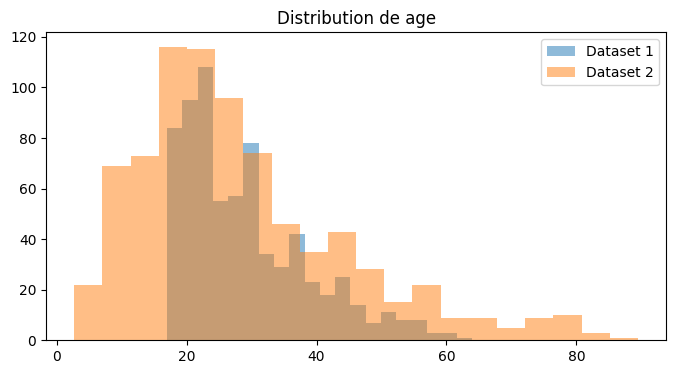


Test KS
Statistique : 0.2531454480796586
p-value : 1.4408239415575995e-21
Distributions différentes

Variable : result

DATASET 1
count    703.000000
mean       4.880512
std        2.498992
min        0.000000
25%        3.000000
50%        4.000000
75%        7.000000
max       10.000000
Name: result, dtype: float64

DATASET 2
count    800.000000
mean       8.537303
std        4.807676
min       -6.137748
25%        5.306575
50%        9.605299
75%       12.514484
max       15.853126
Name: result, dtype: float64

Moyennes
df1 : 4.8805120910384066
df2 : 8.537303106501248

Médianes
df1 : 4.0
df2 : 9.605299308


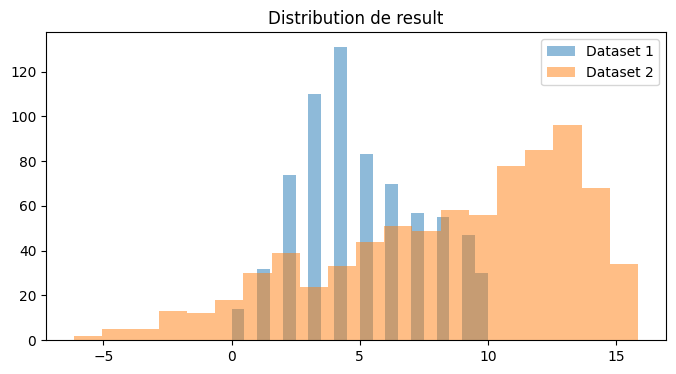


Test KS
Statistique : 0.49732574679943103
p-value : 1.16811258487812e-84
Distributions différentes


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

quant_vars = ["age", "result"]

for col in quant_vars:

    print("\n========================")
    print("Variable :", col)
    print("========================\n")

    print("DATASET 1")
    print(df1[col].describe())

    print("\nDATASET 2")
    print(df2[col].describe())

    print("\nMoyennes")
    print("df1 :", df1[col].mean())
    print("df2 :", df2[col].mean())

    print("\nMédianes")
    print("df1 :", df1[col].median())
    print("df2 :", df2[col].median())

    plt.figure(figsize=(8,4))

    plt.hist(df1[col], bins=20, alpha=0.5, label="Dataset 1")
    plt.hist(df2[col], bins=20, alpha=0.5, label="Dataset 2")

    plt.title(f"Distribution de {col}")
    plt.legend()
    plt.show()

    stat,p = ks_2samp(df1[col],df2[col])

    print("\nTest KS")
    print("Statistique :",stat)
    print("p-value :",p)

    if p < 0.05:
        print("Distributions différentes")
    else:
        print("Distributions comparables")

# 3. Étude des variables qualitatives


### 3.1 Analyse descriptive des variables qualitatives

In [26]:
qual_vars = [
    "gender",
    "ethnicity",
    "autism",
    "jaundice",
    "used_app_before",
    "relation"
]

for var in qual_vars:

    print("\n====================")
    print(var)
    print("====================")

    print("\nDataset 1")
    print(df1[var].value_counts(normalize=True))

    print("\nDataset 2")
    print(df2[var].value_counts(normalize=True))


gender

Dataset 1
gender
m    0.522048
f    0.477952
Name: proportion, dtype: float64

Dataset 2
gender
m    0.6625
f    0.3375
Name: proportion, dtype: float64

ethnicity

Dataset 1
ethnicity
White-European     0.331437
Asian              0.174964
Unknown            0.135135
Middle Eastern     0.130868
Black              0.061166
South Asian        0.051209
Others             0.042674
Latino             0.028450
Hispanic           0.018492
Pasifika           0.015647
Turkish            0.008535
others             0.001422
Name: proportion, dtype: float64

Dataset 2
ethnicity
White-European    0.32125
Unknown           0.25375
Middle Eastern    0.12125
Asian             0.08375
Black             0.05875
South Asian       0.04250
Pasifika          0.04000
Others            0.03625
Latino            0.02125
Hispanic          0.01125
Turkish           0.00625
others            0.00375
Name: proportion, dtype: float64

autism

Dataset 1
autism
no     0.870555
yes    0.129445
Name: proport

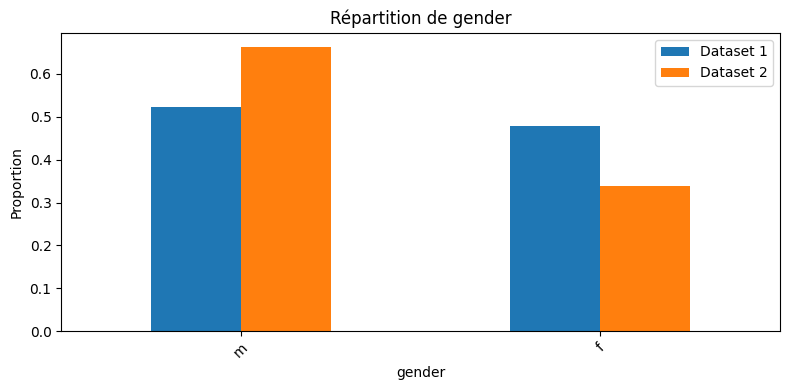

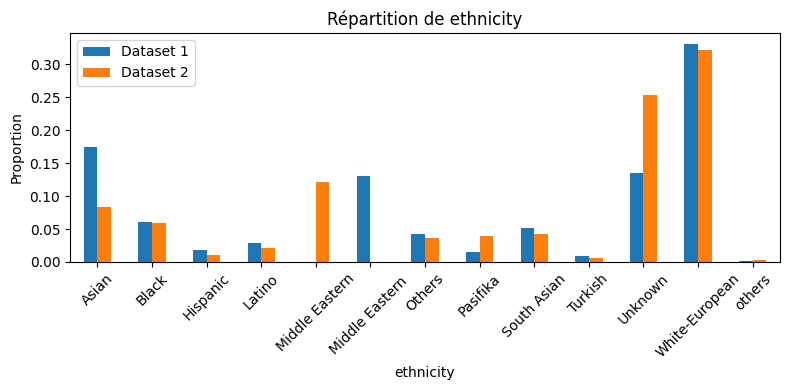

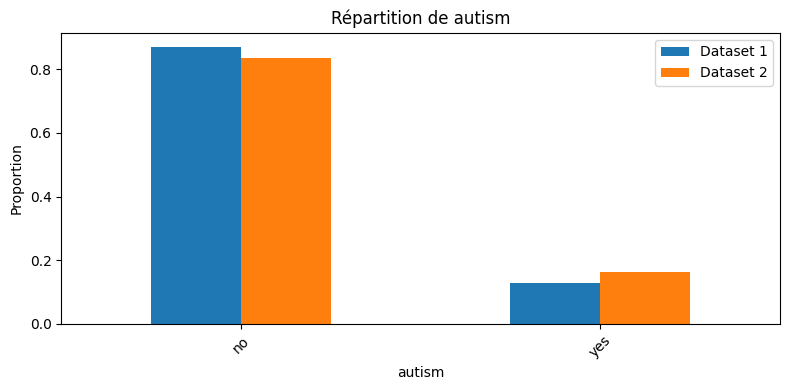

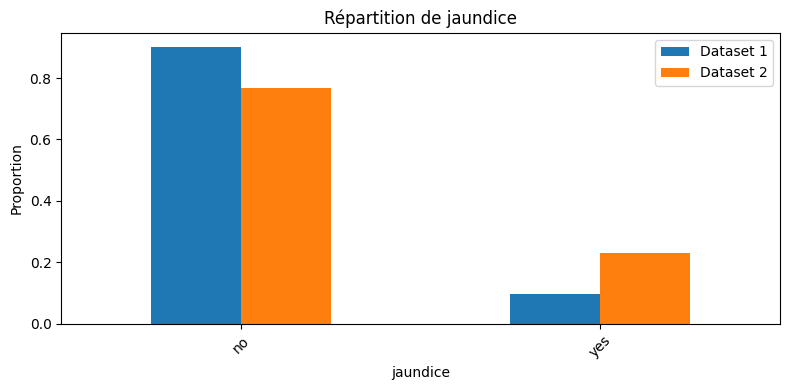

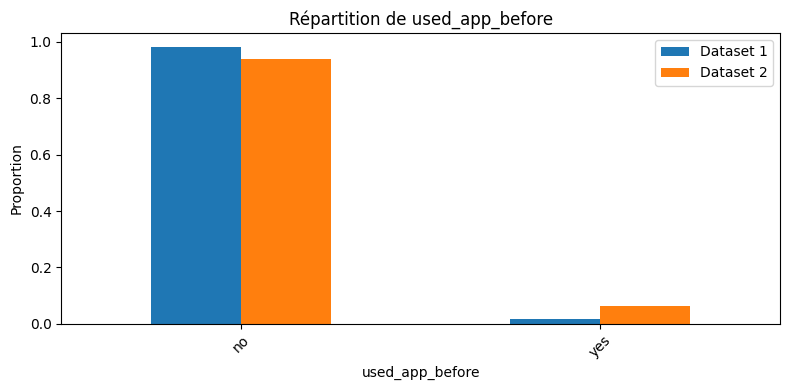

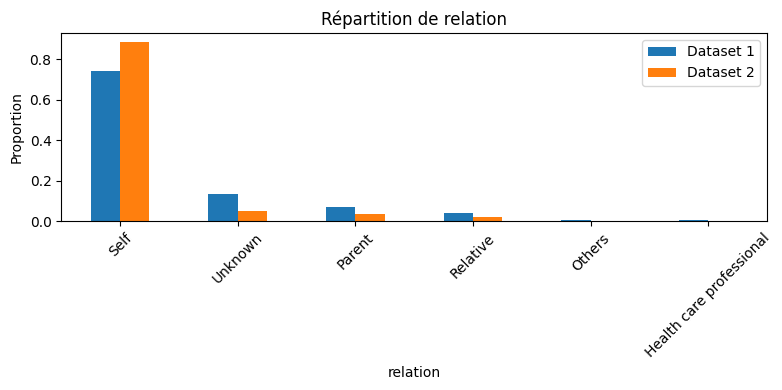

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

qual_vars = [
    "gender",
    "ethnicity",
    "autism",
    "jaundice",
    "used_app_before",
    "relation"
]

for var in qual_vars:

    freq = pd.DataFrame({
        "Dataset 1": df1[var].value_counts(normalize=True),
        "Dataset 2": df2[var].value_counts(normalize=True)
    }).fillna(0)

    freq.plot(kind="bar", figsize=(8,4))

    plt.title(f"Répartition de {var}")
    plt.ylabel("Proportion")
    plt.xlabel(var)
    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.show()

### 3.2 Comparaison statistique des répartitions qualitatives
Ici le test du Chi² est utilisé pour vérifier si les proportions des différentes modalités sont similaires entre les deux datasets.

In [28]:
from scipy.stats import chi2_contingency


for col in qual_vars:

    print("\n========================")
    print("Variable :",col)
    print("========================\n")

    freq1 = df1[col].value_counts(normalize=True)
    freq2 = df2[col].value_counts(normalize=True)

    print("Proportions dataset 1")
    print(freq1)

    print("\nProportions dataset 2")
    print(freq2)

    table = pd.concat([
        df1[col].value_counts(),
        df2[col].value_counts()
    ],axis=1).fillna(0)

    stat,p,dof,expected = chi2_contingency(table)

    print("\nTest Chi²")
    print("p-value :",p)

    if p < 0.05:
        print("Répartition différente")
    else:
        print("Répartition comparable")


Variable : gender

Proportions dataset 1
gender
m    0.522048
f    0.477952
Name: proportion, dtype: float64

Proportions dataset 2
gender
m    0.6625
f    0.3375
Name: proportion, dtype: float64

Test Chi²
p-value : 4.114598543102374e-08
Répartition différente

Variable : ethnicity

Proportions dataset 1
ethnicity
White-European     0.331437
Asian              0.174964
Unknown            0.135135
Middle Eastern     0.130868
Black              0.061166
South Asian        0.051209
Others             0.042674
Latino             0.028450
Hispanic           0.018492
Pasifika           0.015647
Turkish            0.008535
others             0.001422
Name: proportion, dtype: float64

Proportions dataset 2
ethnicity
White-European    0.32125
Unknown           0.25375
Middle Eastern    0.12125
Asian             0.08375
Black             0.05875
South Asian       0.04250
Pasifika          0.04000
Others            0.03625
Latino            0.02125
Hispanic          0.01125
Turkish           0.

# 4. Analyse de la variable cible ASD

Cette partie vise à comparer la répartition des classes ASD entre les datasets.

In [29]:
df2["ASD"] = df2["ASD"].astype(str)

df2["ASD"] = df2["ASD"].replace({
    "0":"NO",
    "1":"YES"
})

In [30]:
df1["ASD"] = df1["ASD"].astype(str)
df2["ASD"] = df2["ASD"].astype(str)

df1["ASD"] = df1["ASD"].replace({
    "0":"NO",
    "1":"YES"
})

df2["ASD"] = df2["ASD"].replace({
    "0":"NO",
    "1":"YES"
})

In [31]:
from scipy.stats import chi2_contingency
import pandas as pd

print("========== DATASET 1 ==========")
print(df1["ASD"].value_counts())
print()
print(df1["ASD"].value_counts(normalize=True))

print("\n========== DATASET 2 ==========")
print(df2["ASD"].value_counts())
print()
print(df2["ASD"].value_counts(normalize=True))

table_asd = pd.concat(
    [
        df1["ASD"].value_counts(),
        df2["ASD"].value_counts()
    ],
    axis=1
).fillna(0)

table_asd.columns = ["Dataset1", "Dataset2"]

print("\nTableau de contingence")
print(table_asd)

chi2, p, dof, expected = chi2_contingency(table_asd)

print("\nRésultat du test du Chi²")
print("Statistique :", chi2)
print("p-value :", p)

if p < 0.05:
    print("Conclusion : répartition différente")
else:
    print("Conclusion : répartition comparable")



========== DATASET 1 ==========
ASD
NO     514
YES    189
Name: count, dtype: int64

ASD
NO     0.731152
YES    0.268848
Name: proportion, dtype: float64

========== DATASET 2 ==========
ASD
NO     639
YES    161
Name: count, dtype: int64

ASD
NO     0.79875
YES    0.20125
Name: proportion, dtype: float64

Tableau de contingence
     Dataset1  Dataset2
ASD                    
NO        514       639
YES       189       161

Résultat du test du Chi²
Statistique : 9.19666193262811
p-value : 0.002424568588174025
Conclusion : répartition différente


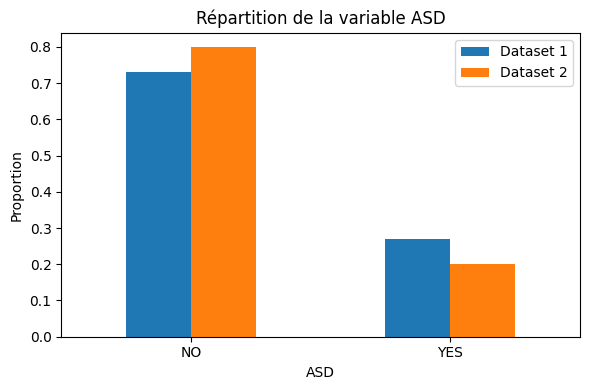

In [32]:
# Proportions ASD dans chaque dataset
freq_asd = pd.DataFrame({
    "Dataset 1": df1["ASD"].value_counts(normalize=True),
    "Dataset 2": df2["ASD"].value_counts(normalize=True)
}).fillna(0)

# Graphique
freq_asd.plot(kind="bar", figsize=(6,4))

plt.title("Répartition de la variable ASD")
plt.ylabel("Proportion")
plt.xlabel("ASD")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

# 5. Étude des relations avec ASD

###5.1 Variables qualitatives
Pour les variables qualitatives, un test du Chi² est utilisé afin d'étudier l'existence d'une association avec ASD.

In [33]:
from scipy.stats import chi2_contingency
import pandas as pd

variables = [
    "gender",
    "autism",
    "jaundice",
    "used_app_before",
    "relation"
]

for var in variables:

    print("\n======================================")
    print("Variable :", var)
    print("======================================")

    print("\nDATASET 1")

    table1 = pd.crosstab(df1[var], df1["ASD"])

    chi2, p, dof, expected = chi2_contingency(table1)

    print("p-value :", p)

    if p < 0.05:
        print("Lien significatif avec ASD")
    else:
        print("Pas de lien significatif avec ASD")

    print("\nDATASET 2")

    table2 = pd.crosstab(df2[var], df2["ASD"])

    chi2, p, dof, expected = chi2_contingency(table2)

    print("p-value :", p)

    if p < 0.05:
        print("Lien significatif avec ASD")
    else:
        print("Pas de lien significatif avec ASD")


Variable : gender

DATASET 1
p-value : 0.038258038571219156
Lien significatif avec ASD

DATASET 2
p-value : 0.9758243168741388
Pas de lien significatif avec ASD

Variable : autism

DATASET 1
p-value : 4.872231911868849e-06
Lien significatif avec ASD

DATASET 2
p-value : 1.0060560058593027e-23
Lien significatif avec ASD

Variable : jaundice

DATASET 1
p-value : 0.010500943513020543
Lien significatif avec ASD

DATASET 2
p-value : 0.00013300658957470307
Lien significatif avec ASD

Variable : used_app_before

DATASET 1
p-value : 0.40283555141683325
Pas de lien significatif avec ASD

DATASET 2
p-value : 0.3745543476430917
Pas de lien significatif avec ASD

Variable : relation

DATASET 1
p-value : 0.002725657023848512
Lien significatif avec ASD

DATASET 2
p-value : 0.0608119481637184
Pas de lien significatif avec ASD


###5.2 Variables quantitatives
Pour les variables quantitatives, le test de Wilcoxon-Mann-Whitney permet de comparer les distributions entre les groupes ASD et non ASD.

In [34]:

from scipy.stats import mannwhitneyu

variables_quant = ["age", "result"]

for var in variables_quant:

    print("\n======================================")
    print("Variable :", var)
    print("======================================")

    print("\nDATASET 1")

    groupe0 = df1[df1["ASD"] == "NO"][var]
    groupe1 = df1[df1["ASD"] == "YES"][var]

    stat, p = mannwhitneyu(groupe0, groupe1)

    print("p-value :", p)

    if p < 0.05:
        print("Différence significative")
    else:
        print("Pas de différence significative")

    print("\nDATASET 2")

    groupe0 = df2[df2["ASD"] == "NO"][var]
    groupe1 = df2[df2["ASD"] == "YES"][var]

    stat, p = mannwhitneyu(groupe0, groupe1)

    print("p-value :", p)

    if p < 0.05:
        print("Différence significative")
    else:
        print("Pas de différence significative")


Variable : age

DATASET 1
p-value : 0.0011495381548677695
Différence significative

DATASET 2
p-value : 0.0018850519755528718
Différence significative

Variable : result

DATASET 1
p-value : 1.8788348184164464e-93
Différence significative

DATASET 2
p-value : 2.753049304410927e-26
Différence significative


# 6. Synthèse des résultats

### 6.1 Comparaison globale des datasets

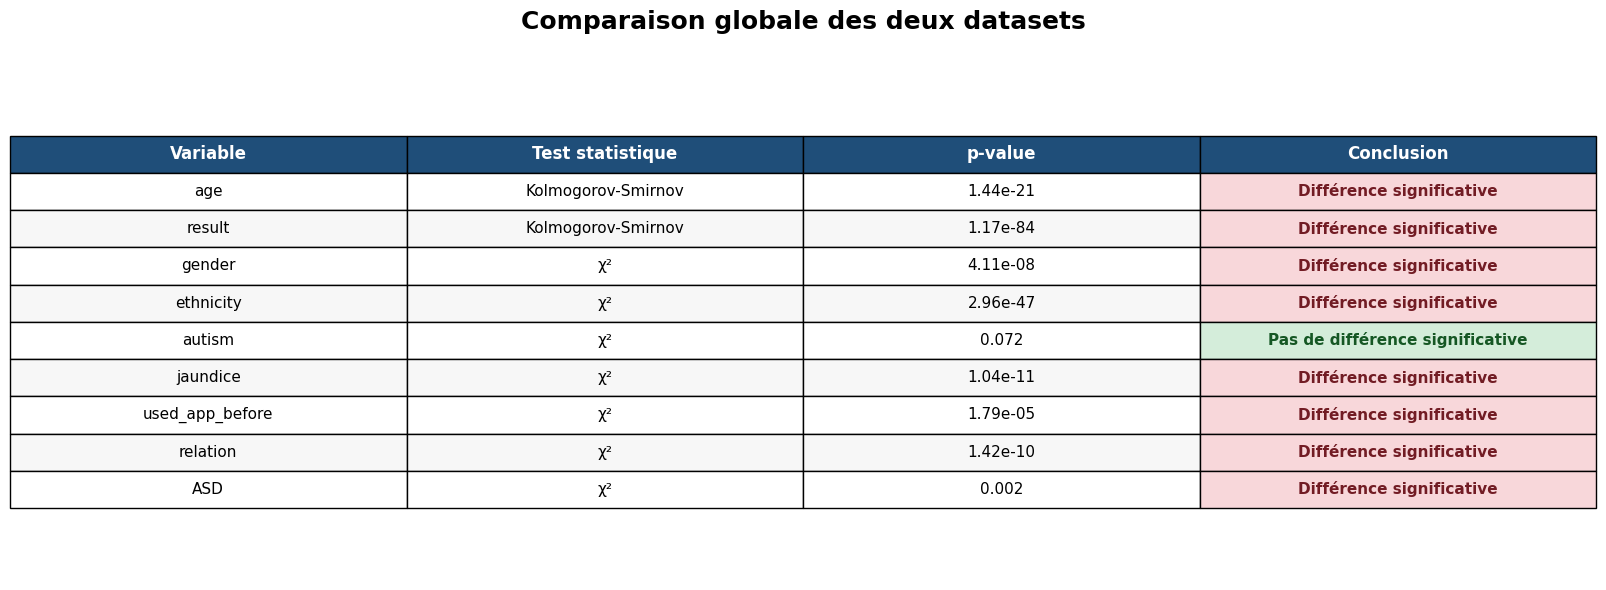

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

def format_pvalue(p):
    if p < 0.001:
        return f"{p:.2e}"
    else:
        return f"{p:.3f}"

tableau = pd.DataFrame({
    "Variable": [
        "age",
        "result",
        "gender",
        "ethnicity",
        "autism",
        "jaundice",
        "used_app_before",
        "relation",
        "ASD"
    ],
    "Test statistique": [
        "Kolmogorov-Smirnov",
        "Kolmogorov-Smirnov",
        "χ²",
        "χ²",
        "χ²",
        "χ²",
        "χ²",
        "χ²",
        "χ²"
    ],
    "p-value": [
        format_pvalue(1.4408239415575995e-21),
        format_pvalue(1.16811258487812e-84),
        format_pvalue(4.114598543102374e-08),
        format_pvalue(2.9630971219384155e-47),
        format_pvalue(0.07226826033197481),
        format_pvalue(1.0361676398447324e-11),
        format_pvalue(1.7949241911281467e-05),
        format_pvalue(1.4221303315354197e-10),
        format_pvalue(0.002424568588174025)
    ],
    "Conclusion": [
        "Différence significative",
        "Différence significative",
        "Différence significative",
        "Différence significative",
        "Pas de différence significative",
        "Différence significative",
        "Différence significative",
        "Différence significative",
        "Différence significative"
    ]
})

fig, ax = plt.subplots(figsize=(16,6))
ax.axis("off")

tab = ax.table(
    cellText=tableau.values,
    colLabels=tableau.columns,
    cellLoc="center",
    loc="center"
)

tab.auto_set_font_size(False)
tab.set_fontsize(11)
tab.scale(1.2, 2)

for j in range(len(tableau.columns)):
    cell = tab[(0, j)]
    cell.set_facecolor("#1f4e79")
    cell.set_text_props(color="white", weight="bold", fontsize=12)

for i in range(1, len(tableau) + 1):
    couleur_ligne = "#f7f7f7" if i % 2 == 0 else "white"

    for j in range(len(tableau.columns)):
        tab[(i, j)].set_facecolor(couleur_ligne)

    conclusion = tableau.iloc[i-1]["Conclusion"]

    if "Pas de différence" in conclusion:
        tab[(i, 3)].set_facecolor("#d4edda")
        tab[(i, 3)].set_text_props(color="#155724", weight="bold")
    else:
        tab[(i, 3)].set_facecolor("#f8d7da")
        tab[(i, 3)].set_text_props(color="#721c24", weight="bold")

plt.title(
    "Comparaison globale des deux datasets",
    fontsize=18,
    fontweight="bold",
    pad=25
)

plt.tight_layout()
plt.show()

### 6.2 Stabilité des relations avec ASD

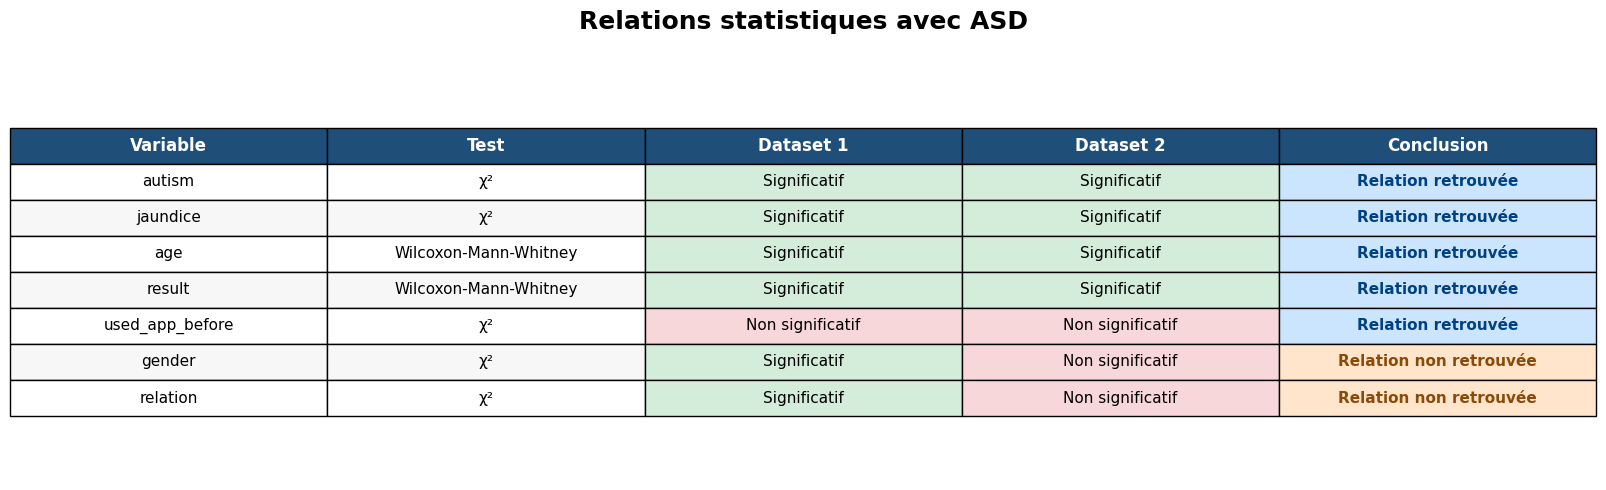

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

tableau = pd.DataFrame({

    "Variable": [
        "autism",
        "jaundice",
        "age",
        "result",
        "used_app_before",
        "gender",
        "relation"
    ],

    "Test": [
        "χ²",
        "χ²",
        "Wilcoxon-Mann-Whitney",
        "Wilcoxon-Mann-Whitney",
        "χ²",
        "χ²",
        "χ²"
    ],

    "Dataset 1": [
        "Significatif",
        "Significatif",
        "Significatif",
        "Significatif",
        "Non significatif",
        "Significatif",
        "Significatif"
    ],

    "Dataset 2": [
        "Significatif",
        "Significatif",
        "Significatif",
        "Significatif",
        "Non significatif",
        "Non significatif",
        "Non significatif"
    ],

    "Conclusion": [
        "Relation retrouvée",
        "Relation retrouvée",
        "Relation retrouvée",
        "Relation retrouvée",
        "Relation retrouvée",
        "Relation non retrouvée",
        "Relation non retrouvée"
    ]
})

fig, ax = plt.subplots(figsize=(16, 5))
ax.axis("off")

tab = ax.table(
    cellText=tableau.values,
    colLabels=tableau.columns,
    cellLoc="center",
    loc="center"
)

tab.auto_set_font_size(False)
tab.set_fontsize(11)
tab.scale(1.2, 2)

for j in range(len(tableau.columns)):
    cell = tab[(0, j)]
    cell.set_facecolor("#1f4e79")
    cell.set_text_props(color="white", weight="bold", fontsize=12)

for i in range(1, len(tableau) + 1):

    couleur = "#f7f7f7" if i % 2 == 0 else "white"

    for j in range(len(tableau.columns)):
        tab[(i, j)].set_facecolor(couleur)

    if tableau.iloc[i-1]["Dataset 1"] == "Significatif":
        tab[(i, 2)].set_facecolor("#d4edda")
    else:
        tab[(i, 2)].set_facecolor("#f8d7da")

    if tableau.iloc[i-1]["Dataset 2"] == "Significatif":
        tab[(i, 3)].set_facecolor("#d4edda")
    else:
        tab[(i, 3)].set_facecolor("#f8d7da")

    if tableau.iloc[i-1]["Conclusion"] == "Relation retrouvée":
        tab[(i, 4)].set_facecolor("#cce5ff")
        tab[(i, 4)].set_text_props(color="#004085", weight="bold")
    else:
        tab[(i, 4)].set_facecolor("#ffe5cc")
        tab[(i, 4)].set_text_props(color="#8a4b08", weight="bold")

plt.title(
    "Relations statistiques avec ASD",
    fontsize=18,
    fontweight="bold",
    pad=25
)

plt.tight_layout()
plt.show()

# 7. Conclusion

Les analyses réalisées montrent que les deux datasets présentent plusieurs différences significatives concernant la distribution de certaines variables quantitatives et qualitatives.

Cependant, plusieurs relations avec ASD sont retrouvées de manière cohérente dans les deux datasets, notamment pour les variables :

- age
- result
- autism
- jaundice
- used_app_before

Ces résultats suggèrent l'existence de relations statistiquement stables malgré les différences observées entre les populations étudiées.

Cette étude constitue une base pertinente pour la partie de modélisation et de classification.